# The Complete Journey — Business Problem, Data, and Plan of Attack

*Customer Survival Analysis on the Dunnhumby dataset*

This notebook is the front door to the Dunnhumby survival-analysis pipeline. It is written for a reader who has never opened the project before. By the end you should understand:

1. **The business problem** — why churn prediction in retail matters and what question we are actually answering.
2. **The dataset** — what Dunnhumby published, how the tables fit together, and why this data is richer than most public retail datasets.
3. **The empirical landscape** — what an EDA of 2.6M transactions reveals about how households shop.
4. **The plan of attack** — the nine-stage pipeline, where it lives in the repo, and why it is structured the way it is.

If you just want results, skip to [DUNNHUMBY_PLAN.md](DUNNHUMBY_PLAN.md). If you want to understand *why* the pipeline looks the way it does, read on.

## 1. The business problem

### Why survival analysis, not classification

Most churn projects frame the task as binary classification: *will customer X churn in the next N days?* That works, but it throws away information. In reality we want to know **when** someone is likely to leave — tomorrow, next month, next quarter — because the right marketing action for an at-risk customer depends on how imminent the risk is.

**Customer survival analysis** recasts the problem in the vocabulary of medical survival studies:

| Medical concept | Customer analogue |
|---|---|
| Patient enrollment | First purchase |
| Time-to-event | Days until the customer becomes inactive for long enough to call them churned |
| Censored observation | Customer still active at the end of the study window |
| Survival function *S(t)* | Probability that a customer is still active *t* days after a reference point |
| Hazard | Instantaneous risk of churning at time *t* |

Concretely, for a grocery retailer we care about three outputs:

1. **A per-household risk score** today — who is on the verge of walking away?
2. **A conditional survival curve** — "given that this household is still active on DAY 500, what is the probability they are still shopping on DAY 530, DAY 560, DAY 590?"
3. **A CLV estimate** — how much revenue will we lose over the next six months if we do nothing?

### Why Dunnhumby

The Dunnhumby "Complete Journey" dataset is unusually rich for a public retail panel:

- **Household-level identity** across two years (vs. the more common session- or transaction-level anonymity).
- **Promotional exposure** — we know which campaigns reached which household and which coupons they redeemed.
- **Demographic overlay** on 32% of households (age, income, household size, kids).
- **Product hierarchy** (department / commodity / brand / private-label flag).

That richness lets us build features the Online Retail II project couldn't — coupon-redemption latency, department concentration, campaign-type mix — and ask much finer-grained business questions.

## 2. The dataset at a glance

Seven CSV files, total ~865 MB. The largest is `causal_data.csv` (~700 MB of product×store×week display/mailer records); we defer it to v2 because it is disk-bound, not information-bound.

| File | Grain | Rows | Role |
|---|---|---|---|
| `transaction_data.csv` | One line item | 2.6M | Every basket scan |
| `product.csv` | One product | 92K | Department / commodity / brand / private-label |
| `hh_demographic.csv` | One household | 801 | Age, income, household composition, kids |
| `campaign_desc.csv` | One campaign | 30 | Campaign type (A/B/C) + active window |
| `campaign_table.csv` | Household × campaign | 7K | Which household received which campaign |
| `coupon.csv` | Coupon × product | 124K | Which coupons apply to which products, inside which campaign |
| `coupon_redempt.csv` | Redemption event | 2.3K | Households that actually redeemed a coupon, when |

Let's load everything and eyeball the shapes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (9, 4.5)

from pathlib import Path
DATA = Path('../../data/dunnhumby')
assert DATA.exists(), f'Data folder not found at {DATA}'
print('Data folder:', DATA.resolve())

Data folder: /Users/josephazar/Desktop/WORK/GITHUB/data/dunnhumby


In [2]:
# Lightweight eyeball of each file — just shape and first 2 rows
files = [
    'transaction_data.csv', 'product.csv', 'hh_demographic.csv',
    'campaign_desc.csv', 'campaign_table.csv', 'coupon.csv',
    'coupon_redempt.csv',
]
for f in files:
    df = pd.read_csv(DATA / f, nrows=2)
    n = sum(1 for _ in open(DATA / f)) - 1
    print(f'{f:24s}  rows={n:>10,d}  cols={df.shape[1]}  head→ {list(df.columns)[:5]}...')

transaction_data.csv      rows= 2,595,732  cols=12  head→ ['household_key', 'BASKET_ID', 'DAY', 'PRODUCT_ID', 'QUANTITY']...
product.csv               rows=    92,353  cols=7  head→ ['PRODUCT_ID', 'MANUFACTURER', 'DEPARTMENT', 'BRAND', 'COMMODITY_DESC']...
hh_demographic.csv        rows=       801  cols=8  head→ ['AGE_DESC', 'MARITAL_STATUS_CODE', 'INCOME_DESC', 'HOMEOWNER_DESC', 'HH_COMP_DESC']...
campaign_desc.csv         rows=        30  cols=4  head→ ['DESCRIPTION', 'CAMPAIGN', 'START_DAY', 'END_DAY']...
campaign_table.csv        rows=     7,208  cols=3  head→ ['DESCRIPTION', 'household_key', 'CAMPAIGN']...
coupon.csv                rows=   124,548  cols=3  head→ ['COUPON_UPC', 'PRODUCT_ID', 'CAMPAIGN']...
coupon_redempt.csv        rows=     2,318  cols=4  head→ ['household_key', 'DAY', 'COUPON_UPC', 'CAMPAIGN']...


### The central fact table

`transaction_data.csv` is the spine. Every other file is either a lookup against it or an auxiliary attribute.

```
transaction_data   ──(household_key)──►  hh_demographic
                   ──(PRODUCT_ID)──►     product
                   ──(household_key)──►  campaign_table ──(CAMPAIGN)──► campaign_desc
                                                        ──(CAMPAIGN)──► coupon ──(COUPON_UPC)──► coupon_redempt
```

One quirk: **`DAY` is an integer 1..711**, not a date. This is Dunnhumby's way of anonymising the real-world dates (roughly 2006–2008 for a US grocery chain). For most analyses we treat `DAY` as a relative day-number. For libraries like `lifetimes` that demand real datetimes, we synthesize one: `DAY = 1 → 2017-01-01`.

In [3]:
# Load the full transaction table and take a first peek
tx_raw = pd.read_csv(DATA / 'transaction_data.csv')
print(f'rows = {len(tx_raw):,}    households = {tx_raw["household_key"].nunique():,}')
print(f'DAY range: {tx_raw["DAY"].min()}..{tx_raw["DAY"].max()}')
tx_raw.head(5)

rows = 2,595,732    households = 2,500
DAY range: 1..711


,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,0.0,0.0
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,0.0,0.0
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,0.0,0.0
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,0.0,0.0
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,0.0,0.0


In [4]:
# Standard cleaning pass:
#   * drop returns (negative QUANTITY) and zero-price lines
#   * synthesize a datetime column for lifetimes compatibility
SYNTHETIC_EPOCH = pd.Timestamp('2017-01-01')
tx = tx_raw[(tx_raw['QUANTITY'] > 0) & (tx_raw['SALES_VALUE'] > 0)].copy()
tx['INVOICE_DATE'] = SYNTHETIC_EPOCH + pd.to_timedelta(tx['DAY'] - 1, unit='D')
print(f'Kept {len(tx):,} / {len(tx_raw):,} rows ({len(tx) / len(tx_raw) * 100:.1f}%)')
print(f'Span: {tx["INVOICE_DATE"].min().date()}  →  {tx["INVOICE_DATE"].max().date()}  ({tx["DAY"].max()} days)')

Kept 2,576,815 / 2,595,732 rows (99.3%)
Span: 2017-01-01  →  2018-12-12  (711 days)


## 3. Exploratory data analysis

### 3.1 How often do households shop?

The single most important exploratory question for a **survival analysis of grocery shoppers** is: *how dense is the purchase cadence?* The answer determines both the natural time unit of the model and the right threshold for calling someone "churned".

In [5]:
# Basket = one (household_key, BASKET_ID). Count baskets per household.
baskets = (tx.groupby(['household_key', 'BASKET_ID'], as_index=False)
             .agg(DAY=('DAY', 'first'), SALES_VALUE=('SALES_VALUE', 'sum')))
basket_counts = baskets.groupby('household_key').size()

print(f'Baskets: {len(baskets):,}')
print(f'Baskets per household — min: {basket_counts.min()}  p25: {basket_counts.quantile(.25):.0f}'
      f'  median: {basket_counts.median():.0f}  p75: {basket_counts.quantile(.75):.0f}'
      f'  max: {basket_counts.max()}')
print(f'One-timer households (exactly 1 basket): {(basket_counts == 1).sum()}')

Baskets: 275,539
Baskets per household — min: 1  p25: 38  median: 78  p75: 142  max: 1298
One-timer households (exactly 1 basket): 3


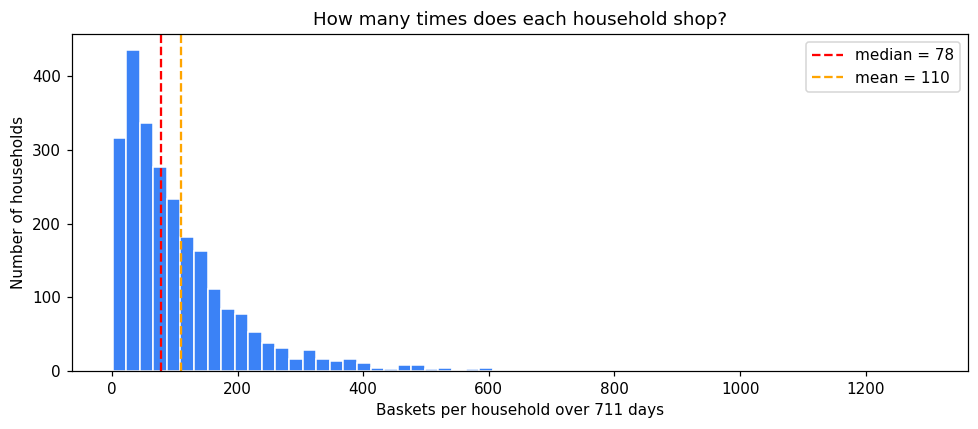

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(basket_counts, bins=60, color='#3b82f6', edgecolor='white')
ax.axvline(basket_counts.median(), color='red', linestyle='--', label=f'median = {basket_counts.median():.0f}')
ax.axvline(basket_counts.mean(), color='orange', linestyle='--', label=f'mean = {basket_counts.mean():.0f}')
ax.set_xlabel('Baskets per household over 711 days')
ax.set_ylabel('Number of households')
ax.set_title('How many times does each household shop?')
ax.legend()
plt.tight_layout(); plt.show()

**What we learn.** Half the households shop more than 78 times over two years, a quarter shop more than 142 times, and the most enthusiastic shopper returns 1,298 times — roughly twice a day. Only **three** households are one-timers. This shape has two big consequences for our analysis:

1. **A "conversion" model à la Online Retail ("will the one-timer come back?") is not the right question here.** There is essentially no positive class. We re-scope Stage 5 to something the data supports: *given a household's first 90 days, will they eventually become inactive by the end of the window?*
2. **The churn threshold needs to be calibrated to this cadence.** A 45-day inactivity window — standard for online retail — would miss most grocery departures. We need something much tighter.

### 3.2 The gap distribution — calibrating the churn window

The right threshold falls out of the inter-basket gap distribution. If the *typical* gap is a week, a 45-day window is far too loose; anything in the 14–21-day range is more plausible.

In [7]:
bb = baskets.sort_values(['household_key', 'DAY'])[['household_key', 'BASKET_ID', 'DAY']].drop_duplicates(['household_key', 'BASKET_ID'])
bb['prev_day'] = bb.groupby('household_key')['DAY'].shift(1)
bb['gap'] = bb['DAY'] - bb['prev_day']
gaps = bb['gap'].dropna()
print(f'Observed gaps: {len(gaps):,}')
for q in [0.50, 0.75, 0.90, 0.95, 0.99]:
    print(f'  p{int(q * 100):2d}:  {gaps.quantile(q):.0f} days')
print(f'   max: {int(gaps.max())} days')

Observed gaps: 273,039
  p50:  2 days
  p75:  6 days
  p90:  12 days
  p95:  20 days
  p99:  54 days
   max: 666 days


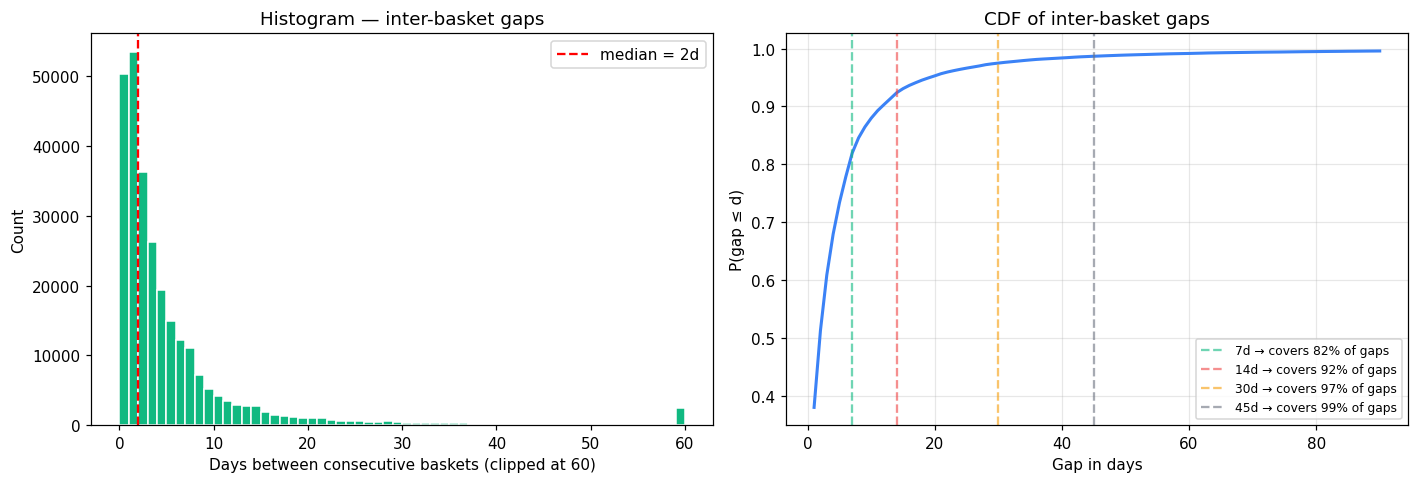

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.hist(gaps.clip(upper=60), bins=60, color='#10b981', edgecolor='white')
ax1.axvline(gaps.median(), color='red', linestyle='--', label=f'median = {gaps.median():.0f}d')
ax1.set_xlabel('Days between consecutive baskets (clipped at 60)')
ax1.set_ylabel('Count')
ax1.set_title('Histogram — inter-basket gaps')
ax1.legend()

max_d = 90
x = np.arange(1, max_d + 1)
cdf = np.array([(gaps <= d).mean() for d in x])
ax2.plot(x, cdf, color='#3b82f6', lw=2)
for threshold, c in [(7, '#10b981'), (14, '#ef4444'), (30, '#f59e0b'), (45, '#6b7280')]:
    p = (gaps <= threshold).mean()
    ax2.axvline(threshold, color=c, linestyle='--', alpha=0.6,
                label=f'{threshold}d → covers {p * 100:.0f}% of gaps')
ax2.set_xlabel('Gap in days')
ax2.set_ylabel('P(gap ≤ d)')
ax2.set_title('CDF of inter-basket gaps')
ax2.legend(fontsize=8, loc='lower right')
ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**What we learn.** The median gap is 2 days; 95% of all gaps are ≤20 days; a 14-day threshold captures about 90% of natural cadence. In stage `02_churn_window_analysis.py` we formalise this with a **Kneedle elbow detection** that lands on 16 days; we round to 14 because it is the cleaner candidate and matches the CDF's shoulder.

*Compare this to Online Retail II, where the same analysis lands on 43 days.* Grocery shopping is an order of magnitude tighter than e-commerce.

### 3.3 Volume over time — is the panel stable?

We want to confirm that the two-year panel does not drift wildly (e.g. a huge spike at Christmas that would distort BTYD fits).

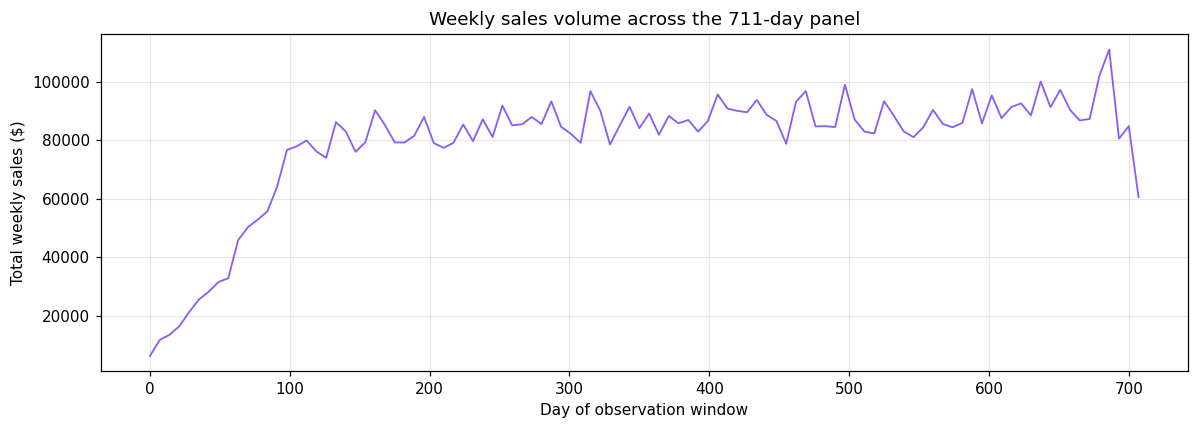

In [9]:
weekly = tx.groupby(tx['DAY'] // 7 * 7)['SALES_VALUE'].sum()
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(weekly.index, weekly.values, color='#8b5cf6', lw=1.2)
ax.set_xlabel('Day of observation window')
ax.set_ylabel('Total weekly sales ($)')
ax.set_title('Weekly sales volume across the 711-day panel')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

The panel is stable with mild seasonality. No single week dominates, so we can fit population-level models without weighting.

### 3.4 What do households actually buy?

Department mix tells us whether this is a "pure grocery" chain or something with meaningful non-food exposure. It also reveals whether we can build features like "grocery dominance" or "drug/GM share".

In [10]:
products = pd.read_csv(DATA / 'product.csv')
dept_spend = (tx.merge(products[['PRODUCT_ID', 'DEPARTMENT']], on='PRODUCT_ID', how='left')
                 .groupby('DEPARTMENT')['SALES_VALUE'].sum()
                 .sort_values(ascending=False)
                 .head(15))
share = (dept_spend / dept_spend.sum()).round(3)
print('Top 15 departments — share of total spend:')
for d, s in share.items():
    print(f'  {d:22s}  {s * 100:5.1f}%')

Top 15 departments — share of total spend:
  GROCERY                  51.1%
  DRUG GM                  13.2%
  PRODUCE                   7.0%
  MEAT                      6.9%
  KIOSK-GAS                 6.8%
  MEAT-PCKGD                5.2%
  DELI                      3.3%
  PASTRY                    1.5%
  MISC SALES TRAN           1.5%
  NUTRITION                 1.2%
  SEAFOOD-PCKGD             0.8%
  FLORAL                    0.5%
  COSMETICS                 0.4%
  SALAD BAR                 0.4%
  SEAFOOD                   0.4%


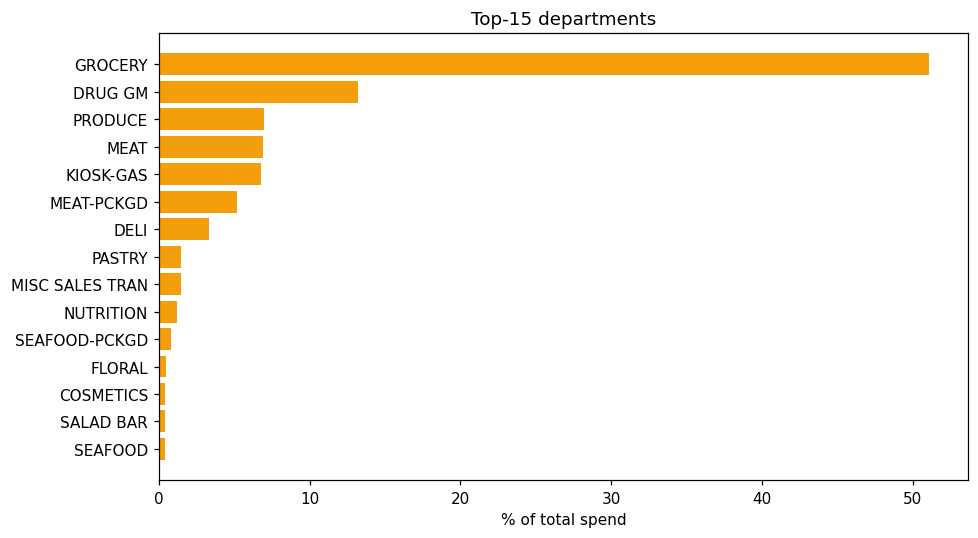

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(share.index[::-1], share.values[::-1] * 100, color='#f59e0b')
ax.set_xlabel('% of total spend')
ax.set_title('Top-15 departments')
plt.tight_layout(); plt.show()

Grocery dominates (51%), followed by drug/general-merchandise (13%) and produce (7%). That distribution motivates our feature engineering: department-share columns are a cheap way to distinguish "pantry-focused" households from "one-stop-shop" households who also buy drug/GM items — the two profiles often have very different churn dynamics.

### 3.5 The promotional layer

This is where Dunnhumby really shines. Most retail datasets give you only the transaction stream; Dunnhumby tells us which campaigns reached which household and which coupons they actually redeemed. That lets us build *responsiveness* features — far better predictors than raw spend.

In [12]:
campaigns = pd.read_csv(DATA / 'campaign_table.csv')
campaign_desc = pd.read_csv(DATA / 'campaign_desc.csv')
coupon_redempt = pd.read_csv(DATA / 'coupon_redempt.csv')

print(f'Distinct campaigns: {campaigns["CAMPAIGN"].nunique()}')
print(f'Campaign types: {campaign_desc["DESCRIPTION"].value_counts().to_dict()}')
print(f'Households receiving any campaign: {campaigns["household_key"].nunique():,} ({campaigns["household_key"].nunique() / 2500 * 100:.0f}% of panel)')
print(f'Total coupon redemptions: {len(coupon_redempt):,}')
print(f'Households that redeemed ≥1 coupon: {coupon_redempt["household_key"].nunique():,} ({coupon_redempt["household_key"].nunique() / 2500 * 100:.0f}% of panel)')

Distinct campaigns: 30
Campaign types: {'TypeB': 19, 'TypeC': 6, 'TypeA': 5}
Households receiving any campaign: 1,584 (63% of panel)
Total coupon redemptions: 2,318
Households that redeemed ≥1 coupon: 434 (17% of panel)


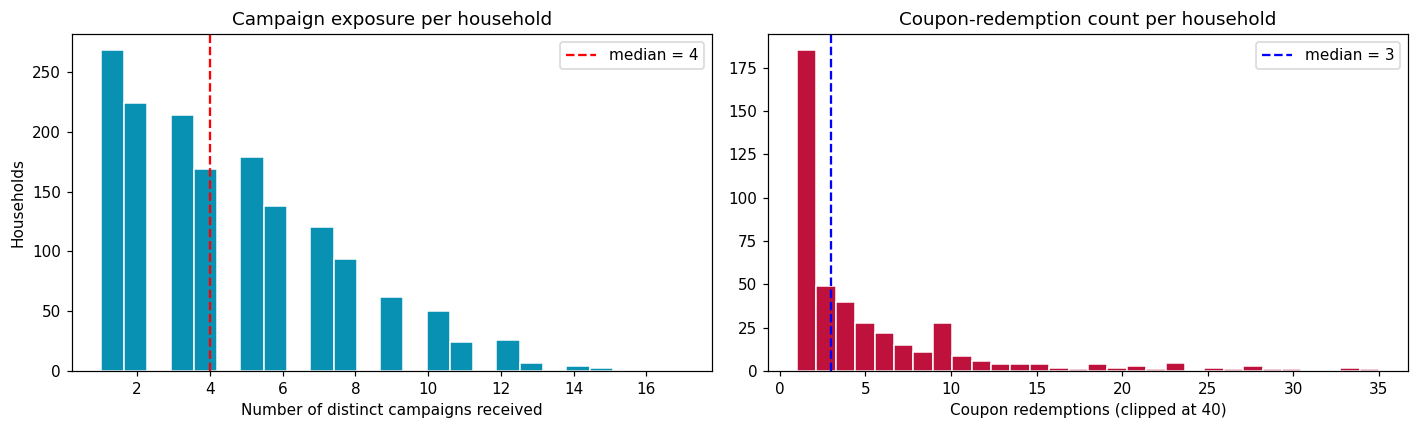

In [13]:
# How do campaign exposures spread across households?
exposure_count = campaigns.groupby('household_key')['CAMPAIGN'].nunique()
redempt_count = coupon_redempt.groupby('household_key')['COUPON_UPC'].count()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.hist(exposure_count, bins=25, color='#0891b2', edgecolor='white')
ax1.axvline(exposure_count.median(), color='red', linestyle='--', label=f'median = {exposure_count.median():.0f}')
ax1.set_xlabel('Number of distinct campaigns received')
ax1.set_ylabel('Households')
ax1.set_title('Campaign exposure per household')
ax1.legend()

ax2.hist(redempt_count.clip(upper=40), bins=30, color='#be123c', edgecolor='white')
ax2.axvline(redempt_count.median(), color='blue', linestyle='--', label=f'median = {redempt_count.median():.0f}')
ax2.set_xlabel('Coupon redemptions (clipped at 40)')
ax2.set_title('Coupon-redemption count per household')
ax2.legend()
plt.tight_layout(); plt.show()

We get natural-experiment-style variation here: some households receive three campaigns, some receive twenty. In the feature matrix we turn this into `n_campaigns_pre`, `n_typeA/B/C_pre`, and `coupon_redempt_per_campaign_pre`.

### 3.6 Demographics — the trade-off

Only **801 of 2,500** households (32%) have demographic data. That is a meaningful constraint.

In [14]:
demo = pd.read_csv(DATA / 'hh_demographic.csv')
print(f'Households with demographics: {len(demo):,} / 2,500 ({len(demo) / 2500 * 100:.0f}%)')
demo.head()

Households with demographics: 801 / 2,500 (32%)


,AGE_DESC,MARITAL_STATUS_CODE,INCOME_DESC,HOMEOWNER_DESC,HH_COMP_DESC,HOUSEHOLD_SIZE_DESC,KID_CATEGORY_DESC,household_key
0,65+,A,35-49K,Homeowner,2 Adults No Kids,2,None/Unknown,1
1,45-54,A,50-74K,Homeowner,2 Adults No Kids,2,None/Unknown,7
2,25-34,U,25-34K,Unknown,2 Adults Kids,3,1,8
3,25-34,U,75-99K,Homeowner,2 Adults Kids,4,2,13
4,45-54,B,50-74K,Homeowner,Single Female,1,None/Unknown,16


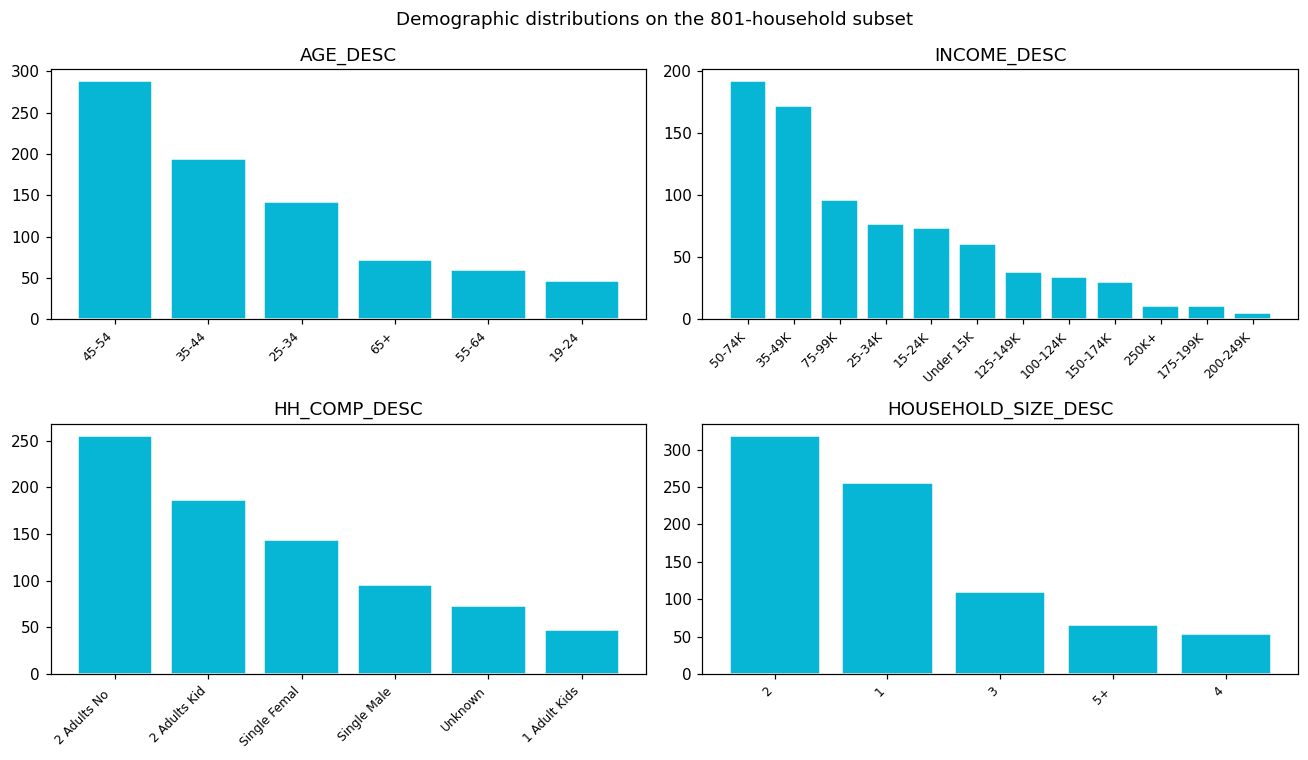

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, col in zip(axes.flat, ['AGE_DESC', 'INCOME_DESC', 'HH_COMP_DESC', 'HOUSEHOLD_SIZE_DESC']):
    vc = demo[col].value_counts()
    ax.bar(range(len(vc)), vc.values, color='#06b6d4', edgecolor='white')
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels([str(x)[:12] for x in vc.index], rotation=45, ha='right', fontsize=8)
    ax.set_title(col)
fig.suptitle('Demographic distributions on the 801-household subset')
plt.tight_layout(); plt.show()

**Design decision.** We have two options:

1. Train a *separate* model on the 801 demographic-rich households. Thin data, but cleaner attribution for "does income predict churn?".
2. Treat `Unknown` as a valid category, add a binary `HAS_DEMOGRAPHICS` flag, and train one unified model. Lose some interpretability, keep all 2,500 households.

We go with **Option 2**. Statistical power matters more than clean attribution for a scorecard.

## 4. Key insights from EDA

| Finding | Implication for modelling |
|---|---|
| Median inter-basket gap = 2 days; p95 = 20 days | Churn threshold = 14 days (vs 45d for Online Retail) |
| Only 3 one-timer households | Original "Stage 1 conversion" task is not applicable — we reframe to an early-behaviour churn classifier |
| Dense shopping (median 78 baskets/HH) | Survival event times are short; a 211-day follow-up window is more than enough to observe churn |
| 13 departments with meaningful share | Department-mix and concentration features are worth building |
| 99% of households received ≥1 campaign | Promotional responsiveness is a strong differentiating signal |
| Only 32% have demographics | Unified model with `Unknown` imputation, not a sub-model |
| Panel is temporally stable | Safe to fit population-level BG/NBD without time weighting |

## 5. The plan of attack

### Why landmark analysis?

A *landmark* is a fixed day in the observation window (we use DAY 500). We use it to cleanly separate **"what we know about a household"** from **"what we are trying to predict"**:

- Features are built **strictly** from transactions on or before DAY 500.
- The survival target is measured **from DAY 500 forward**. Event time is `last_basket_day + churn_window − landmark_day` for churners, and `MAX_DAY − landmark_day = 211` for households still active at the study end.

This design solves three problems at once:

1. **No feature leakage** — nothing in the feature matrix has seen post-landmark data, so recency and trend features cannot secretly encode the outcome.
2. **Correct time axis** — event times are on the same axis as the prediction we make at the landmark ("will this household still be active 30 days from now?").
3. **Clean censoring** — households who never churn in the follow-up window are censored at DAY 711, not at their last basket.

### Pipeline overview

```
00_data_prep           ─►  Clean + enrich + synthesize dates
01_eda                 ─►  Diagnostic plots + summary JSON
02_churn_window        ─►  Kneedle elbow → 14d
03_feature_engineering ─►  Landmark feature matrix + leakage report
04_btyd_benchmark      ─►  BG/NBD + Gamma-Gamma (for CLV comparison only)
05_early_dropout       ─►  First-90d features → eventual-churn classifier
06_survival_analysis   ─►  CoxPH / CoxNet / RSF / GBSA / XGB AFT
                         + conditional S(Δ) for the scorecard
07_clv_benchmark       ─►  ML vs BTYD on a clean 450/630/711 split
08_household_scorecard ─►  Final risk tiers + CSV export

tests/test_leakage_and_smoke.py — 14 automated assertions
```

Each stage writes a parquet intermediate to `processed/` and plot/metric artifacts to `artifacts/<stage>/`.

### Expected deliverables

1. **A per-household risk tier** (Low / Medium / High / Churned) on the 2,500 households.
2. **Conditional 30/60/90/180-day survival curves** for the ~1,767 households alive at the landmark.
3. **A CLV benchmark** comparing ML regressors against BTYD on 180-day forward spend.
4. **A leakage-tested codebase** — every methodological claim in the README is backed by a test assertion.

## 6. Next steps

Run the pipeline end-to-end from `dunnhumby/scripts/`:

```bash
cd scripts
for s in 00_data_prep 01_eda 02_churn_window_analysis 03_feature_engineering \
         04_btyd_benchmark 05_early_dropout_model 06_customer_survival_analysis \
         07_clv_prediction_benchmark 08_household_scorecard; do
  ../../venv/bin/python $s.py
done
cd .. && ../venv/bin/python tests/test_leakage_and_smoke.py
```

Or dive into the specific stages:

- [`03_feature_engineering.py`](scripts/03_feature_engineering.py) — where the landmark feature matrix is built. Worth reading line-by-line if you want to see how the `event_time` and `event_observed` targets are defined.
- [`06_customer_survival_analysis.py`](scripts/06_customer_survival_analysis.py) — the five survival models side by side. Good place to start if you've used survival tools before.
- [`tests/test_leakage_and_smoke.py`](tests/test_leakage_and_smoke.py) — the 14 invariants the pipeline maintains. If you change any upstream logic, these should still pass.

For the full v1 → v2 fix log (why this pipeline looks the way it does), see [`DUNNHUMBY_PLAN.md`](DUNNHUMBY_PLAN.md).